In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullFormatter

In [4]:
loss_lst = ['mse','pcc','si-snr','dtw', 'ours']
lengths = [256, 512, 1024, 2048, 4096]
base_time =[[10.96, 9.74, 9.72, 9.62, 9.63],
           [11.03, 10.53, 10.50, 10.51, 8.95],
           [11.12, 9.40, 9.44, 9.44, 9.28],
           [50.26, 254.90, 1070.54, 3789.83, 19321.26],
           [11.64, 10.60, 10.57, 10.50, 10.40]]
base_peak = [[22.82, 29.50, 37.40, 52.75, 84.34],
             [22.80, 29.46, 37.31, 52.57, 83.97],
             [22.82, 29.50, 37.40, 52.75, 84.31],
             [56.65, 168.69, 605.19, 2342.20, 9274.59],
             [22.83, 29.52, 37.43, 52.82, 84.47]
            ]

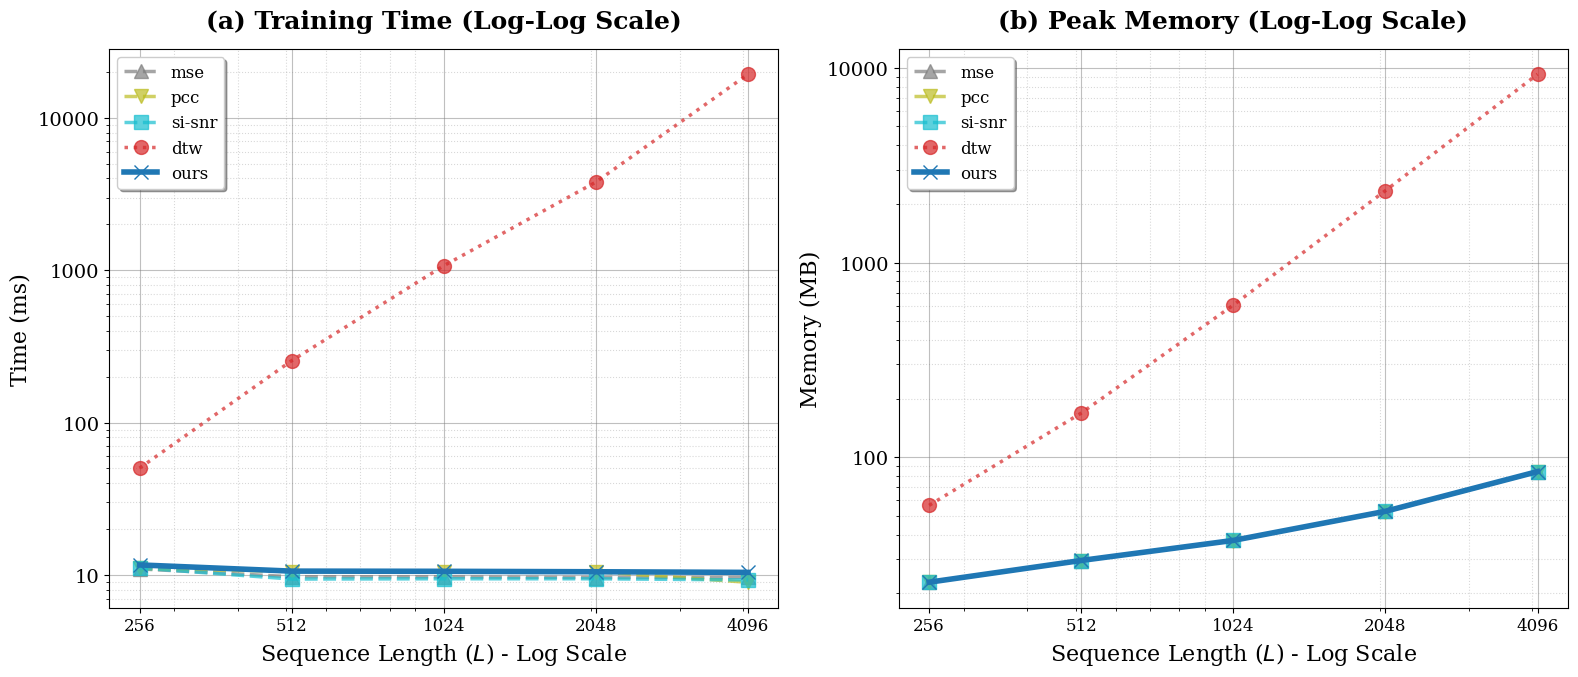

In [14]:
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#7f7f7f', '#bcbd22', '#17becf', '#d62728', '#1f77b4'] 
markers = ['^', 'v', 's', 'o', 'x'] 
linestyles = ['--', '--', '--', ':', '-']

metrics_data = [base_time, base_peak]
titles = ['(a) Training Time (Log-Log Scale)', '(b) Peak Memory (Log-Log Scale)']
y_labels = ['Time (ms)', 'Memory (MB)']

for ax_idx, ax in enumerate(axes):
    current_data = metrics_data[ax_idx]
    
    for i, model_name in enumerate(loss_lst):
        y_data = current_data[i]
        valid_x = [x for x, y in zip(lengths, y_data) if y is not None]
        valid_y = [y for y in y_data if y is not None]
        
        is_ours = 'ours' in model_name.lower() or 'sdsc' in model_name.lower()
        lw = 4.0 if is_ours else 2.5 # 선을 더 굵게
        alpha = 1.0 if is_ours else 0.7
        zorder = 10 if is_ours else 5 
        
        ax.plot(valid_x, valid_y, 
                marker=markers[i], color=colors[i], linestyle=linestyles[i],
                linewidth=lw, markersize=10, alpha=alpha, zorder=zorder, label=model_name)
        
        # OOM 표시
        if len(valid_x) < len(lengths):
            oom_x = lengths[len(valid_x)]
            last_y = valid_y[-1]
            ax.scatter([oom_x], [last_y * 1.5], marker='O', s=200, color='red', zorder=20)
            if ax_idx == 1:
                ax.text(oom_x, last_y * 1.5, " OOM", color='red', fontsize=12, fontweight='bold', va='center')

    # --- [핵심] X축, Y축 모두 로그 스케일 (Log-Log) ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    # -----------------------------------------------

    # 그리드 설정 (Log scale의 핵심은 촘촘한 그리드)
    ax.grid(True, which='major', linestyle='-', alpha=0.5, color='gray')
    ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='gray')

    # 축 제목 및 라벨
    ax.set_title(titles[ax_idx], fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Sequence Length ($L$) - Log Scale', fontsize=16)
    ax.set_ylabel(y_labels[ax_idx], fontsize=16)

    # --- [디테일] 축 눈금 숫자 포맷팅 (10^2 대신 100으로 표시) ---
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(ScalarFormatter())
        axis.set_minor_formatter(NullFormatter()) # 작은 눈금 숫자는 생략

    # X축에 우리가 실험한 Length만 강제로 표시
    ax.set_xticks(lengths)
    ax.set_xticklabels([str(l) for l in lengths], fontsize=12)

    # 범례
    ax.legend(fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig("benchmark_result.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()